Starting W1: [[ 0.04967142 -0.01382643  0.06476885  0.15230299]]
Starting W2: [[-0.02341534]
 [-0.0234137 ]
 [ 0.15792128]
 [ 0.07674347]]
Step 0 | Loss: 1.214399
Step 20 | Loss: 0.944321
Step 40 | Loss: 0.163674
Step 60 | Loss: 0.002030
Step 80 | Loss: 0.000011
Step 100 | Loss: 0.000000
Step 120 | Loss: 0.000000
Step 140 | Loss: 0.000000
Step 160 | Loss: 0.000000
Step 180 | Loss: 0.000000


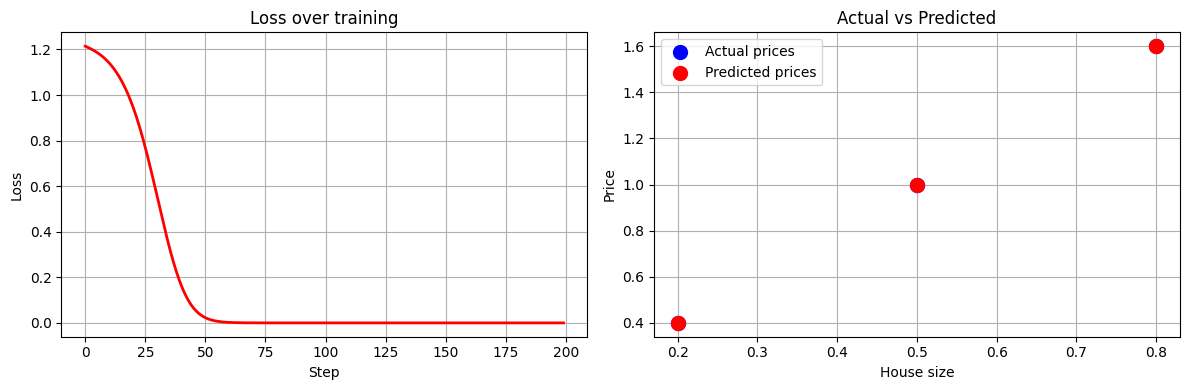

Test house size: 0.35
Network predicted: 0.7000
Actual answer:     0.7000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Input data — house sizes (normalized between 0 and 1)
X = np.array([[0.2], [0.5], [0.8]])
# Output data — house prices
y = np.array([0.4, 1.0, 1.6])

# Random starting weights
np.random.seed(42)   # makes randomness consistent so we get same results
W1 = np.random.randn(1, 4) * 0.1   # first layer — 1 input, 4 neurons
W2 = np.random.randn(4, 1) * 0.1   # second layer — 4 neurons, 1 output

print("Starting W1:", W1)
print("Starting W2:", W2)

def relu(x):
    return np.maximum(0, x)

def forward(x, W1, W2):
    # Layer 1
    hidden = relu(x @ W1)   # shape: (3, 4)
    # Layer 2
    output = hidden @ W2    # shape: (3, 1)
    return hidden, output

def loss(output, actual):
    return np.mean((output - actual.reshape(-1, 1)) ** 2)

learning_rate = 0.1
losses = []

for step in range(200):
    # Forward pass
    hidden, output = forward(X, W1, W2)

    # Calculate loss
    current_loss = loss(output, y)
    losses.append(current_loss)

    # Backpropagation — calculate gradients
    output_error = output - y.reshape(-1, 1)

    dW2 = hidden.T @ output_error / len(X)

    hidden_error = output_error @ W2.T
    hidden_error[hidden <= 0] = 0   # ReLU gradient

    dW1 = X.T @ hidden_error / len(X)
    # Update weights
    W1 -= learning_rate * dW1
    W2 -= learning_rate * dW2

    if step % 20 == 0:
        print(f"Step {step} | Loss: {current_loss:.6f}")

plt.figure(figsize=(12, 4))

# Plot 1 — loss curve
plt.subplot(1, 2, 1)
plt.plot(losses, color='red', linewidth=2)
plt.title("Loss over training")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)

# Plot 2 — predictions vs actual
plt.subplot(1, 2, 2)
_, predictions = forward(X, W1, W2)
plt.scatter(X, y, color='blue', s=100, label='Actual prices', zorder=5)
plt.scatter(X, predictions, color='red', s=100, label='Predicted prices', zorder=5)
plt.title("Actual vs Predicted")
plt.xlabel("House size")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Test the network on a house size it never saw before
test_size = np.array([[0.35]])   # never seen this during training

_, predicted_price = forward(test_size, W1, W2)
actual_price = 0.35 * 2   # real answer

print(f"Test house size: 0.35")
print(f"Network predicted: {predicted_price[0][0]:.4f}")
print(f"Actual answer:     {actual_price:.4f}")